In [4]:
import pandas as pd

# Load the dataset
df = pd.read_csv('credit_card_fraud_10k.csv')

# Print the exact column names
print("Your dataset columns are:")
print(list(df.columns))

Your dataset columns are:
['transaction_id', 'amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'is_fraud']


In [5]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('credit_card_fraud_10k.csv')

# --- Checklist Analysis ---
total_records = len(df)
class_counts = df['is_fraud'].value_counts()

legit_count = class_counts.get(0, 0)
fraud_count = class_counts.get(1, 0)
fraud_percentage = (fraud_count / total_records) * 100

print(f"Total Transactions: {total_records}")
print(f"Legitimate Transactions (0): {legit_count}")
print(f"Fraudulent Transactions (1): {fraud_count}")
print(f"Percentage of Fraudulent Transactions: {fraud_percentage:.3f}%")

Total Transactions: 10000
Legitimate Transactions (0): 9849
Fraudulent Transactions (1): 151
Percentage of Fraudulent Transactions: 1.510%


C:\Users\91704\AppData\Local\Temp\ipykernel_12440\974084312.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_fraud', y='amount', palette='Set1')


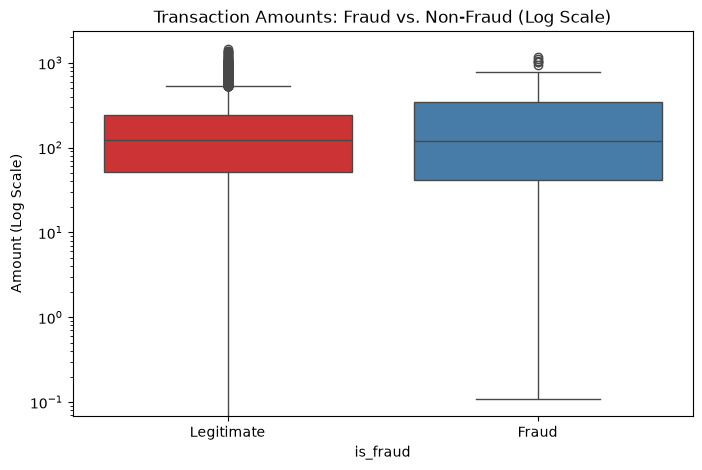

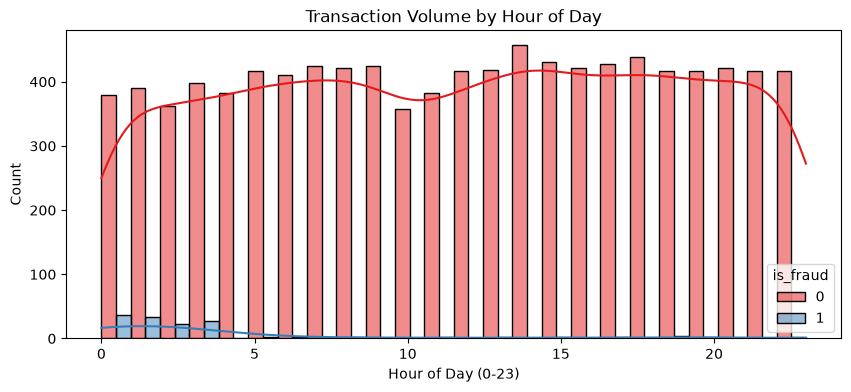

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribution of transaction amounts
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='is_fraud', y='amount', palette='Set1')
plt.yscale('log')
plt.title('Transaction Amounts: Fraud vs. Non-Fraud (Log Scale)')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.ylabel('Amount (Log Scale)')
plt.show()

# 2. Time-of-day analysis using your 'transaction_hour' column
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='transaction_hour', hue='is_fraud', bins=24, multiple='dodge', kde=True, palette='Set1', common_norm=False)
plt.title('Transaction Volume by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

# Drop identifier columns and convert category columns to numbers automatically
X = df.drop(columns=['transaction_id', 'is_fraud'])
X = pd.get_dummies(X, drop_first=True) 
y = df['is_fraud']

# Stratification preserves the fraud ratio in splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (8000, 11)
Testing set size: (2000, 11)



==================== Logistic Regression ====================
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1970
           1       0.26      0.97      0.41        30

    accuracy                           0.96      2000
   macro avg       0.63      0.96      0.69      2000
weighted avg       0.99      0.96      0.97      2000


==================== Random Forest ====================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      0.87      0.93        30

    accuracy                           1.00      2000
   macro avg       1.00      0.93      0.96      2000
weighted avg       1.00      1.00      1.00      2000



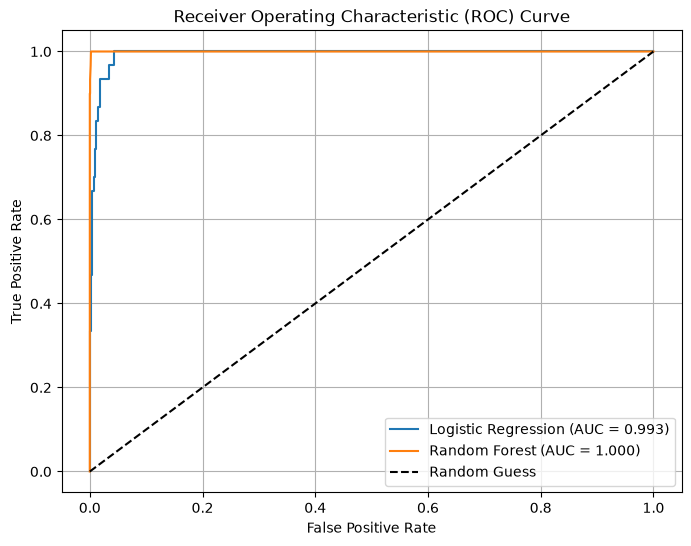

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# We add class_weight='balanced' here to satisfy the imbalance requirement!
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42, n_jobs=-1)
}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    # Train directly on our stratified training data
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(f"\n==================== {name} ====================")
    print(classification_report(y_test, y_pred))
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

###  Step 8: Metric Performance Analysis (Recall vs. Precision)

For a fraud detection system, **Recall matters most**. 

* **Recall (Sensitivity):** Measures what percentage of actual fraud cases were caught by our model.
* **Precision:** Measures how often the model is correct when it flags a transaction as fraud.

**The Trade-off:** 
If we maximize Recall to catch every single thief, the model becomes hypersensitive, creating false positives that temporarily freeze customer accounts. If we maximize Precision to avoid annoying safe users, the model lets actual fraud pass unnoticed. Financial institutions always prioritize Recall because the structural cost of clearing an innocent false alarm is vastly cheaper than absorbing the catastrophic liability of undetected financial crime.

In [10]:
# Step 9: Feature Importance
rf_model = models["Random Forest"]
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance Score': rf_model.feature_importances_})

print("--- TOP 10 STRONGEST PREDICTIVE FEATURES ---")
print(importance_df.sort_values(by='Importance Score', ascending=False).head(10).to_string(index=False))

--- TOP 10 STRONGEST PREDICTIVE FEATURES ---
                      Feature  Importance Score
             transaction_hour          0.241490
           device_trust_score          0.237331
          foreign_transaction          0.163058
            velocity_last_24h          0.136990
            location_mismatch          0.124281
                       amount          0.050159
               cardholder_age          0.027569
    merchant_category_Grocery          0.005330
     merchant_category_Travel          0.005264
merchant_category_Electronics          0.005003


###  Step 10: Scalability Analysis (Handling 1 Million Transactions/Hour)

Processing 1 million transactions per hour translates to roughly **278 transactions per second (TPS)** continuous workload. To scale this model from our notebook into a production enterprise pipeline, the architecture requires these modifications:

1. **Inference Latency Optimization:** Deep Random Forests create high computational memory overhead. For real-time scoring, the trained model should be compiled into a high-speed runtime (like ONNX) or moved to highly parallelized gradient-boosting frameworks like LightGBM or XGBoost.
2. **Real-time Feature Stores:** Individual customer profiles (like `velocity_last_24h`) must update instantly. Features should be computed upstream using stream-processing layers (e.g., Apache Flink) and stored in low-latency in-memory databases like Redis.
3. **Decoupled Messaging & Microservices:** Transactions should enter an immutable streaming queue (like Apache Kafka). Dedicated fraud-scoring worker nodes running inside containerized clusters (Docker/Kubernetes) can pull messages from Kafka and scale out horizontally when transaction spikes occur during high-volume shopping windows.
